# Condition number computation

In [2]:
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import splu, LinearOperator, onenormest
from basix.ufl import element, mixed_element
from ufl import TestFunctions, TrialFunctions, ds, FacetNormal, dx, grad, curl, div, inner, TrialFunction, TestFunction, cross
# from slepc4py import SLEPc
import numpy as np
from dolfinx.fem import dirichletbc, Function, functionspace, form, locate_dofs_topological
from mpi4py import MPI
from dolfinx.fem.petsc import assemble_matrix
from dolfinx.mesh import create_box, locate_entities_boundary, CellType, GhostMode, exterior_facet_indices
import sys

def par_print(string):
    if MPI.COMM_WORLD.rank == 0:
        print(string)
        sys.stdout.flush()


In [3]:
def condest(A, splu_opt={}, onenormest_opt={}):
    """
    Compute an estimate of the 1-norm condition number of a sparse matrix.

    Parameters
    ----------
    A : (M, M) sparse matrix
        square matrix to be inverted
    splu_opt : dict, optional
        Additional named arguments to `splu`.
    onenormest_opt : dict, optional
        Additional named arguments to `onenormest`.

    Returns
    -------
    c : {float, inf}
        The condition number of the matrix. May be infinite.

    Examples
    --------
    >>> from numpy.linalg import cond
    >>> from scipy.sparse import csc_matrix
    >>> A = csc_matrix([[1., 0., 0.], [5., 8., 2.], [0., -1., 0.]], dtype=float)
    >>> A.toarray()
    array([[ 1.,  0.,  0.],
           [ 5.,  8.,  2.],
           [ 0., -1.,  0.]])
    >>> condest(A)
    45.0
    >>> cond(A.toarray(), p=1)
    45.0
    """

    # Check the input sparse matrix.
    if A.ndim != 2:
        raise ValueError('expected the matrix to have two dimensions')
    if A.shape[0] != A.shape[1]:
        raise ValueError('expected the matrix to be square')
    if A.shape[0] == 0:
        raise ValueError('cond is not defined on empty arrays')

    # Get LU decomposition of the matrix.
    try:
        decomposition = splu(A, **splu_opt)
    except RuntimeError:
        return np.inf

    # Function for solving the equation system (original matrix).
    def matvec(rhs): return decomposition.solve(rhs, trans="N")

    # Function for solving the equation system (Hermitian matrix).
    def rmatvec(rhs): return decomposition.solve(rhs, trans="H")

    # Create a linear operator for the matrix inverse.
    op = LinearOperator(A.shape, matvec=matvec, rmatvec=rmatvec)

    # Compute the 1-norm of the matrix inverse (estimate).
    nrm_inv = onenormest(op, **onenormest_opt)

    # Compute the 1-norm of the matrix (estimate).
    nrm_ori = onenormest(A, **onenormest_opt)

    # Compute an estimate of the condition number.
    c = nrm_ori*nrm_inv

    return c


In [4]:
def print_maximum_aspect_ratio(mesh):
    """
    Compute and print the maximum element aspect ratio of a 3D mesh.

    Parameters:
    - mesh: The FEniCSx mesh object.
    """

    # Check if the mesh connectivity from cells to vertices is available
    if mesh.topology.connectivity(mesh.topology.dim, 0) is None:
        mesh.topology.create_connectivity(mesh.topology.dim, 0)

    # Get cell-to-vertex connectivity
    cell_to_vertex = mesh.topology.connectivity(mesh.topology.dim, 0)
    vertex_coords = mesh.geometry.x

    # Get the local range of cell indices
    num_cells_local = mesh.topology.index_map(mesh.topology.dim).size_local
    cell_indices = np.arange(num_cells_local, dtype=np.int32)

    max_aspect_ratio_local = 0.0

    for cell_index in cell_indices:
        # Get the indices of the vertices of the cell
        vertex_indices = cell_to_vertex.links(cell_index)
        num_vertices = len(vertex_indices)
        if num_vertices != 4:
            raise ValueError("Non-tetrahedral cell detected.")

        # Get the coordinates of the vertices
        coords = vertex_coords[vertex_indices]  # Shape: (4, 3)

        # Compute pairwise differences using broadcasting
        diff = coords[:, np.newaxis, :] - coords[np.newaxis, :, :]  # Shape: (4, 4, 3)

        # Compute distances for upper triangle indices
        triu_indices = np.triu_indices(num_vertices, k=1)
        edge_lengths = np.linalg.norm(diff[triu_indices], axis=1)

        max_edge_length = np.max(edge_lengths)

        # Compute the volume of the tetrahedron
        v0, v1, v2, v3 = coords
        a = v1 - v0
        b = v2 - v0
        c = v3 - v0
        volume = abs(np.dot(np.cross(a, b), c)) / 6.0

        if volume <= 0:
            raise ValueError(f"Non-positive volume detected in cell {cell_index}.")

        # Compute the aspect ratio
        aspect_ratio = max_edge_length / (volume ** (1/3))

        if aspect_ratio > max_aspect_ratio_local:
            max_aspect_ratio_local = aspect_ratio

    # Gather the maximum aspect ratios from all processes
    max_aspect_ratio_global = MPI.COMM_WORLD.allreduce(max_aspect_ratio_local, op=MPI.MAX)

    if MPI.COMM_WORLD.rank == 0:
        print(f"Maximum element aspect ratio: {max_aspect_ratio_global}")


In [5]:
import gmsh
from dolfinx.io import gmshio

def create_cylinder_mesh(radius=0.2, height=0.7, element_size=0.5, verbose = False):
    """
    Create a cylindrical mesh with specified radius, height, and element size.
    
    Parameters:
    - radius: Radius of the cylinder.
    - height: Height of the cylinder.
    - element_size: Desired mesh element size (diameter).
    
    Returns:
    - mesh: The generated mesh for FEniCSx.
    """
    gmsh.initialize()
    gmsh.option.setNumber("General.Terminal", 0) # Suppress gmsh output messages
    gmsh.option.setNumber("Mesh.Algorithm", 6)  # 6 for Frontal-Delaunay
    # gmsh.option.setNumber("Mesh.CharacteristicLengthFactor", element_size)
    gmsh.option.setNumber("Mesh.Optimize", 1)     # Optimize mesh quality
    gmsh.option.setNumber("Mesh.OptimizeNetgen", 1) # Optimize mesh quality using Netgen
    # gmsh.option.setNumber("Mesh.Smoothing", 10)

    gmsh.model.add("cylinder")
    
    # Create a cylinder with specified radius and height
    xc, yc, zc = 0, 0, 0
    gmsh.model.occ.addCylinder(xc, yc, zc, 0, 0, height, radius)
    # cylinder = gmsh.model.occ.addCylinder(xc, yc, zc, 0, 0, height, radius, tag=1)

    # Synchronize and mesh
    gmsh.model.occ.synchronize()

    # gmsh.model.mesh.setTransfiniteCurve(1, numNodes=6)  # Align on circle 1
    # gmsh.model.mesh.setTransfiniteCurve(2, numNodes=2)  # Align on connecting line
    # gmsh.model.mesh.setTransfiniteCurve(3, numNodes=6)  # Align on circle 2
    # gmsh.model.mesh.setTransfiniteSurface(2)              # Apply transfinite on surfaces
    
    # Add physical group for the 3D volume
    gmsh.model.addPhysicalGroup(3, [1])  # Volume (3D)
    gmsh.model.addPhysicalGroup(2, [2, 3])  # Surfaces (2D)
    # gmsh.model.addPhysicalGroup(1, [5, 6, 7])  # Lines (1D)
    # gmsh.model.add_physical_group(dim=3, tags=[cylinder])
    
    # Set mesh element size
    gmsh.model.mesh.setSize(gmsh.model.getEntities(0), element_size)
    gmsh.model.mesh.generate(dim=3)
    
    if verbose:
        # Get mesh nodes and cells
        node_tags, _, _ = gmsh.model.mesh.getNodes()
        num_nodes_before = len(node_tags)
        elements = gmsh.model.mesh.getElements(dim=3)
        num_cells_before = len(elements[1][0])  # Assuming there is one element type
        print(f"Number of nodes: {num_nodes_before}")
        print(f"Number of elements: {num_cells_before}")

    # Convert to FEniCSx mesh
    mesh, _, _ = gmshio.model_to_mesh(gmsh.model, MPI.COMM_WORLD, 0)
    
    gmsh.finalize()

    if verbose:
        # Get information about nodes and elements in FEniCSx mesh
        num_nodes_after = mesh.topology.index_map(0).size_local
        num_cells_after = mesh.topology.index_map(mesh.topology.dim).size_local
        print(f"Number of vertices in FEniCSx mesh: {num_nodes_after}")
        print(f"Number of elements (cells) in FEniCSx mesh: {num_cells_after}")
    
    return mesh


In [6]:
import gmsh
from dolfinx.io import gmshio

def create_cylinder_mesh_2(radius=0.2, height=0.7, n_refinements=0, verbose=False):
    gmsh.initialize()
    gmsh.option.setNumber("General.Terminal", 0)  # Suppress gmsh output messages
    gmsh.option.setNumber("Mesh.Algorithm", 6)    # 6 for Frontal-Delaunay
    gmsh.option.setNumber("Mesh.Optimize", 1)     # Optimize mesh quality
    gmsh.option.setNumber("Mesh.OptimizeNetgen", 1)
    gmsh.option.setNumber("Mesh.Smoothing", 10)

    gmsh.model.add("cylinder")

    # Create a cylinder with specified radius and height
    xc, yc, zc = 0, 0, 0
    cylinder = gmsh.model.occ.addCylinder(xc, yc, zc, 0, 0, height, radius)

    # Synchronize and prepare for meshing
    gmsh.model.occ.synchronize()

    # Get the tags of the curves and surfaces
    curves = gmsh.model.getEntities(dim=1)
    surfaces = gmsh.model.getEntities(dim=2)
    volumes = gmsh.model.getEntities(dim=3)

    # Set transfinite curves (number of divisions increases with refinement)
    n_divisions_base = 8  # Base number of divisions
    n_divisions = n_divisions_base * (2 ** n_refinements)
    for curve in curves:
        gmsh.model.mesh.setTransfiniteCurve(curve[1], n_divisions)

    # Set transfinite surfaces and volumes
    # for surface in surfaces:
    #     gmsh.model.mesh.setTransfiniteSurface(surface[1])
    # for volume in volumes:
    #     gmsh.model.mesh.setTransfiniteVolume(volume[1])

    # Add physical groups
    gmsh.model.addPhysicalGroup(3, [vol[1] for vol in volumes], tag=1)
    gmsh.model.addPhysicalGroup(2, [surf[1] for surf in surfaces], tag=2)

    # Generate the mesh
    gmsh.model.mesh.generate(dim=3)

    if verbose:
        # Get mesh nodes and cells
        node_tags, _, _ = gmsh.model.mesh.getNodes()
        num_nodes_before = len(node_tags)
        elements = gmsh.model.mesh.getElements(dim=3)
        num_cells_before = len(elements[1][0])  # Assuming there is one element type
        print(f"Number of nodes: {num_nodes_before}")
        print(f"Number of elements: {num_cells_before}")

    # Convert to FEniCSx mesh
    mesh, _, _ = gmshio.model_to_mesh(gmsh.model, MPI.COMM_WORLD, 0)

    gmsh.finalize()

    if verbose:
        # Get information about nodes and elements in FEniCSx mesh
        num_nodes_after = mesh.topology.index_map(0).size_local
        num_cells_after = mesh.topology.index_map(mesh.topology.dim).size_local
        print(f"Number of vertices in FEniCSx mesh: {num_nodes_after}")
        print(f"Number of elements (cells) in FEniCSx mesh: {num_cells_after}")

    return mesh


In [ ]:
# TEST CREATE CYLINDER MESH
from dolfinx.io import XDMFFile

# gmsh.finalize()
# Example: Create a mesh of a cylinder and visualize
mesh = create_cylinder_mesh(radius=0.2, height=0.7, element_size=1./20, verbose=True)

# with XDMFFile(MPI.COMM_WORLD, "meshes/test.xdmf", "w") as file:
#     file.write_mesh(mesh)

## Wave

In [2]:
def assemble_and_cond(V, bcs):
    # Define problem
    u, v = TrialFunction(V), TestFunction(V)
    eigenval_sq = 1.6
    a = form(inner(curl(u), curl(v)) * dx - eigenval_sq*inner(u, v) * dx)
    # b = form(2*inner(u, v) * dx)

    # Assemble matrices
    A_petsc = assemble_matrix(a, bcs, diagonal=1.0)
    A_petsc.assemble()

    # Convert PETSc matrix to SciPy CSR format
    csr_data = A_petsc.getValuesCSR()
    indptr, indices, data = csr_data
    A = csr_matrix((data, indices, indptr), shape=A_petsc.getSize())

    # Estimate the 1-norm condition number
    # condest_1norm = onenormest(A)
    condest_1norm = condest(A)

    print("Estimated 1-norm condition number of matrix A:", condest_1norm)
    return condest_1norm


conds = np.zeros(3)
# Domain corners
corners = ((0.0, 0.0, 0.0), (np.pi, np.pi, np.pi))
# Number of elements in each direction
n = 7

for i in range(3):
    comm = MPI.COMM_WORLD

    par_print("Right diagonal mesh:")
    mesh = create_box(
        comm,
        corners, (n, n, n),
        CellType.tetrahedron,
        ghost_mode=GhostMode.none)
    mesh.topology.create_connectivity(mesh.topology.dim - 1, mesh.topology.dim)

    # Nédélec
    V_n = functionspace(mesh, ("N1curl", 1))
    # Set boundary DOFs to 0 (u x n = 0 on \partial \Omega).
    bc_facets = exterior_facet_indices(mesh.topology)
    bc_dofs = locate_dofs_topological(V_n, mesh.topology.dim - 1, bc_facets)
    u_bc = Function(V_n)
    with u_bc.x.petsc_vec.localForm() as loc:
        loc.set(0)
    bcs_nedelec = [dirichletbc(u_bc, bc_dofs)]

    # Copmute condition number of Maxwell eigenvalue problem
    conds[i] = assemble_and_cond(V_n, bcs_nedelec)
    n = n*2


Right diagonal mesh:
Estimated 1-norm condition number of matrix A: 5346.534963838469
Right diagonal mesh:
Estimated 1-norm condition number of matrix A: 22780.71637865882
Right diagonal mesh:


## Kikuchi

In [39]:
def assemble_and_cond_kikuchi(V, bcs_dirichlet):
    # Define problem variables
    eigenval_sq = 1.6
    (u, p) = TrialFunctions(V)
    (v, q) = TestFunctions(V)

    a11 = inner(curl(u), curl(v)) * dx - eigenval_sq * inner(u, v) * dx
    a12 = inner(grad(p), v) * dx
    a21 = inner(u, grad(q)) * dx
    a = form(a11 + a12 + a21)

    # # Assemble the matrix
    A_petsc = assemble_matrix(a, bcs_dirichlet, diagonal=1.0)
    A_petsc.assemble()

    # # Get last diagonal entries of PETSc matrix
    # diagonal_vec = A_petsc.getDiagonal()
    # diagonal = diagonal_vec.getArray()
    # num_last_entries = 100  # Number of last entries to check
    # last_entries = diagonal[-num_last_entries:]
    # print(f"Last {num_last_entries} diagonal entries:", last_entries)

    # Convert PETSc matrix to SciPy CSR format
    csr_data = A_petsc.getValuesCSR()
    indptr, indices, data = csr_data
    A = csr_matrix((data, indices, indptr), shape=A_petsc.getSize())

    # Estimate the 1-norm condition number
    # condest_1norm = onenormest(A)
    condest_1norm = condest(A)

    print("Estimated 1-norm condition number of matrix A:", condest_1norm)
    return condest_1norm


conds = np.zeros(3)
# Domain corners
corners = ((0.0, 0.0, 0.0), (np.pi, np.pi, np.pi))
# Number of elements in each direction
n = 7

for i in range(2):
    comm = MPI.COMM_WORLD

    par_print("Right diagonal mesh:")
    mesh = create_box(
        comm,
        corners, (n, n, n),
        CellType.tetrahedron,
        ghost_mode=GhostMode.none)
    mesh.topology.create_connectivity(mesh.topology.dim - 1, mesh.topology.dim)
    print_maximum_aspect_ratio(mesh)

    # Nédélec space (for u and v)
    V_n_el = element("N1curl", mesh.basix_cell(), 1) # Q_el = element("BDMCF", msh.basix_cell(), k)
    # Continuous Lagrange space (for p and q)
    V_c_el = element("Lagrange", mesh.basix_cell(), 1)
    V_el = mixed_element([V_n_el, V_c_el])

    V_n = functionspace(mesh, V_n_el)
    V_c = functionspace(mesh, V_c_el)
    V = functionspace(mesh, V_el)

    # Set boundary conditions for MIXED space
    bc_facets_dirichlet = exterior_facet_indices(mesh.topology)
    bc_dofs_dirichlet = locate_dofs_topological(V, mesh.topology.dim - 1, bc_facets_dirichlet)
    u_bc = Function(V)
    with u_bc.x.petsc_vec.localForm() as loc:
        loc.set(0)
    bcs_dirichlet = [dirichletbc(u_bc, bc_dofs_dirichlet)]

    # Set boundary conditions for Lagrange space
    # bc_facets_dirichlet = exterior_facet_indices(mesh.topology)
    # bc_dofs_dirichlet = locate_dofs_topological(V_c, mesh.topology.dim - 1, bc_facets_dirichlet)
    # u_bc = Function(V_c)
    # with u_bc.x.petsc_vec.localForm() as loc:
    #     loc.set(0)
    # bcs_dirichlet = [dirichletbc(u_bc, bc_dofs_dirichlet)]

    # Compute condition number of Maxwell eigenvalue problem with Kikuchi formulation
    conds[i] = assemble_and_cond_kikuchi(V, bcs_dirichlet)
    n = n * 2


Right diagonal mesh:
Maximum element aspect ratio: 3.1473451902649443
Estimated 1-norm condition number of matrix A: 5442.387988162631
Right diagonal mesh:
Maximum element aspect ratio: 3.1473451902649443
Estimated 1-norm condition number of matrix A: 21215.459192762017


## Kikuchi weak Lagrange BC

In [32]:
def assemble_and_cond_kikuchi(V, bcs_dirichlet, h):
    # Define problem variables
    eigenval_sq = 1.6
    (u, p) = TrialFunctions(V)
    (v, q) = TestFunctions(V)

    a11 = inner(curl(u), curl(v)) * dx - eigenval_sq * inner(u, v) * dx
    a12 = inner(grad(p), v) * dx
    a21 = inner(u, grad(q)) * dx
    a22 = inner(1./h*p, q) * ds
    a = form(a11 + a12 + a21 + a22)

    # # Assemble the matrix
    A_petsc = assemble_matrix(a, bcs_dirichlet, diagonal=1.0)
    # A_petsc = assemble_matrix(a)
    A_petsc.assemble()

    # # Get last diagonal entries of PETSc matrix
    # diagonal_vec = A_petsc.getDiagonal()
    # diagonal = diagonal_vec.getArray()
    # num_last_entries = 100  # Number of last entries to check
    # last_entries = diagonal[-num_last_entries:]
    # print(f"Last {num_last_entries} diagonal entries:", last_entries)

    # Convert PETSc matrix to SciPy CSR format
    csr_data = A_petsc.getValuesCSR()
    indptr, indices, data = csr_data
    A = csr_matrix((data, indices, indptr), shape=A_petsc.getSize())

    # Estimate the 1-norm condition number
    # condest_1norm = onenormest(A)
    condest_1norm = condest(A)

    print("Estimated 1-norm condition number of matrix A:", condest_1norm)
    return condest_1norm


conds = np.zeros(3)
# Domain corners
corners = ((0.0, 0.0, 0.0), (np.pi, np.pi, np.pi))
# Number of elements in each direction
n = 7

for i in range(2):
    comm = MPI.COMM_WORLD

    par_print("Right diagonal mesh:")
    mesh = create_box(
        comm,
        corners, (n, n, n),
        CellType.tetrahedron,
        ghost_mode=GhostMode.none)
    mesh.topology.create_connectivity(mesh.topology.dim - 1, mesh.topology.dim)

    # Nédélec space (for u and v)
    V_n_el = element("N1curl", mesh.basix_cell(), 1) # Q_el = element("BDMCF", msh.basix_cell(), k)
    # Continuous Lagrange space (for p and q)
    V_c_el = element("Lagrange", mesh.basix_cell(), 1)
    V_el = mixed_element([V_n_el, V_c_el])

    V_n = functionspace(mesh, V_n_el)
    V_c = functionspace(mesh, V_c_el)
    V = functionspace(mesh, V_el)

    # Set boundary conditions for Nédélec space
    bc_facets_dirichlet = exterior_facet_indices(mesh.topology)
    bc_dofs_dirichlet = locate_dofs_topological(V_n, mesh.topology.dim - 1, bc_facets_dirichlet)
    u_bc = Function(V_n)
    with u_bc.x.petsc_vec.localForm() as loc:
        loc.set(0)
    bcs_dirichlet = [dirichletbc(u_bc, bc_dofs_dirichlet)]

    # Compute condition number of Maxwell eigenvalue problem with Kikuchi formulation
    conds[i] = assemble_and_cond_kikuchi(V, bcs_dirichlet, 1./n)
    n = n * 2


Right diagonal mesh:
Estimated 1-norm condition number of matrix A: 4012.2855862676715
Right diagonal mesh:
Estimated 1-norm condition number of matrix A: 22122.401248137066


## Kikuchi weak BC with cylinder mesh

In [13]:
def assemble_and_cond_kikuchi(mesh, V, bcs_dirichlet, h, verbose=False):
    # Define problem variables
    eigenval_sq = 1.2
    (u, p) = TrialFunctions(V)
    (v, q) = TestFunctions(V)
    n = FacetNormal(mesh)

    a11 = inner(curl(u), curl(v)) * dx - eigenval_sq * inner(u, v) * dx
    a12 = inner(grad(p), v) * dx
    a21 = inner(u, grad(q)) * dx

    # a12 -= inner(curl(u), cross(n,v)) * ds
    # a21 -= inner(cross(n,u), curl(v)) * ds
    # a11 += inner(10**2 * 1./h * cross(n,u), cross(n,v)) * ds
    a22 = inner(10**2 * 1./h * p, q) * ds

    # a = form(a11 + a12 + a21)
    a = form(a11 + a12 + a21 + a22)

    # Assemble the matrix
    A_petsc = assemble_matrix(a, bcs_dirichlet, diagonal=1.0)
    # A_petsc = assemble_matrix(a)

    A_petsc.assemble()

    # # Get last diagonal entries of PETSc matrix
    diagonal_vec = A_petsc.getDiagonal()
    diagonal = diagonal_vec.getArray()
    num_last_entries = 100  # Number of last entries to check
    last_entries = diagonal[-num_last_entries:]
    print(f"Last {num_last_entries} diagonal entries:", last_entries)
    print(f"Dimension of matrix: {len(diagonal)}")

    # Convert PETSc matrix to SciPy CSR format
    csr_data = A_petsc.getValuesCSR()
    indptr, indices, data = csr_data
    A = csr_matrix((data, indices, indptr), shape=A_petsc.getSize())

    # Estimate the 1-norm condition number
    # condest_1norm = onenormest(A)
    condest_1norm = condest(A)

    print("Estimated 1-norm condition number of matrix A:", condest_1norm)
    return condest_1norm

conds = np.zeros(3)
hs = np.zeros(3)
# Number of elements in each direction
n = 7

for i in range(3):
    comm = MPI.COMM_WORLD

    # mesh = create_cylinder_mesh(radius=0.2, height=0.7, element_size=1./n)
    mesh = create_cylinder_mesh_2(radius=0.2, height=0.7, n_refinements=i)
    print_maximum_aspect_ratio(mesh)

    # Nédélec space (for u and v)
    V_n_el = element("N1curl", mesh.basix_cell(), 1) # Q_el = element("BDMCF", msh.basix_cell(), k)
    # Continuous Lagrange space (for p and q)
    V_c_el = element("Lagrange", mesh.basix_cell(), 1)
    V_el = mixed_element([V_n_el, V_c_el])

    V_n = functionspace(mesh, V_n_el)
    V_c = functionspace(mesh, V_c_el)
    V = functionspace(mesh, V_el)


    # Check dimension of V_n
    # print(f"Dimension of V_n: {V_n.dofmap.index_map.size_global * V_n.dofmap.index_map_bs}")
    # V_c = functionspace(mesh, V_c_el)
    # print(f"Dimension of V_c: {V_c.dofmap.index_map.size_global * V_c.dofmap.index_map_bs}")
    # print(mesh.topology.cell_type)
    # # Number of vertices (nodes)
    # num_vertices = mesh.topology.index_map(0).size_local
    # print(f"Number of nodes: {num_vertices}")
    # # Number of edges (1-dimensional entities)
    # num_edges = mesh.topology.index_map(1).size_local
    # print(f"Number of edges: {num_edges}")
    # # Number of faces (2-dimensional entities)
    # num_faces = mesh.topology.index_map(2).size_local
    # print(f"Number of faces: {num_faces}")
    # # Number of cells (3-dimensional entities)
    # num_cells = mesh.topology.index_map(3).size_local
    # print(f"Number of cells: {num_cells}")

    # Set boundary conditions for MIXED space
    # bc_facets_dirichlet = exterior_facet_indices(mesh.topology)
    # bc_dofs_dirichlet = locate_dofs_topological(V, mesh.topology.dim - 1, bc_facets_dirichlet)
    # u_bc = Function(V)
    # with u_bc.x.petsc_vec.localForm() as loc:
    #     loc.set(0)
    # bcs_dirichlet = [dirichletbc(u_bc, bc_dofs_dirichlet)]

    # Set boundary conditions for Nedelec space
    # bc_facets_dirichlet = exterior_facet_indices(mesh.topology)
    # bc_dofs_dirichlet = locate_dofs_topological(V_n, mesh.topology.dim - 1, bc_facets_dirichlet)
    # u_bc = Function(V_n)
    # with u_bc.x.petsc_vec.localForm() as loc:
    #     loc.set(0)
    # bcs_dirichlet = [dirichletbc(u_bc, bc_dofs_dirichlet)]

    # Set boundary conditions for Lagrange space
    bc_facets_dirichlet = exterior_facet_indices(mesh.topology)
    bc_dofs_dirichlet = locate_dofs_topological(V_c, mesh.topology.dim - 1, bc_facets_dirichlet)
    u_bc = Function(V_c)
    with u_bc.x.petsc_vec.localForm() as loc:
        loc.set(0)
    bcs_dirichlet = [dirichletbc(u_bc, bc_dofs_dirichlet)]

    # Compute condition number of Maxwell eigenvalue problem with Kikuchi formulation
    conds[i] = assemble_and_cond_kikuchi(mesh, V, bcs_dirichlet, 1./n)
    hs[i] = 1./n
    n = n * 2


Maximum element aspect ratio: 3.7850512633798683
Last 100 diagonal entries: [40.91988954 39.92058036 35.37847649 47.89764042  0.         29.2544116
 20.67028949 15.33850555  6.59607398 21.90055711 34.98811707 38.59051985
 13.45301469 43.09631512 13.88869783  7.83923696 25.41346873 28.55174393
 13.27982839  7.44091746 43.37500575 13.07589183 13.28902115  8.02109951
 45.08173458 23.72502227 24.78049099 38.23333982 13.29987548 13.5500693
  7.94342184 38.99912597 36.35039704 27.75511467 23.24087321  3.01775302
 37.17189512 30.13549472 35.16922858  2.71393844  9.92800771  8.31885279
 34.42417902 52.58252658 17.00387722 12.76991421 29.24422709  9.83801717
 50.79164658 38.22291078 29.79748635 35.49010634  2.13024712 41.85168394
 23.62935651 28.94799928  3.07493993 35.18769461 39.77910976  8.48870245
 13.83110294  7.72928199 14.16509641 46.9365357  47.76208538 43.49906764
  0.         38.24950505 77.78747629 19.00575503 18.94415054 15.1697993
 17.7177231  30.75231763  6.13278834 18.79996546 46

# 3-field strong BC with cylinder mesh

In [25]:
from petsc4py import PETSc

def assemble_and_cond_3field(mesh, V, bcs_dirichlet, h, i, verbose=False):
    # Define problem variables
    eigenval_sq = 1.2
    (w, u, p) = TrialFunctions(V)
    (t, v, q) = TestFunctions(V)
    # n = FacetNormal(mesh)

    a0 = inner(w, t) * dx - inner(u, curl(t)) * dx
    a1 = -inner(curl(w), v) * dx + eigenval_sq * inner(u, v) * dx + inner(p, div(v)) * dx
    a2 = inner(div(u), q) * dx

    a = form(a0 + a1 + a2)

    # Assemble the matrix
    # A_petsc = assemble_matrix(a, bcs_dirichlet, diagonal=1.0)
    A_petsc = assemble_matrix(a)

    A_petsc.assemble()

    # # Get last diagonal entries of PETSc matrix
    # diagonal_vec = A_petsc.getDiagonal()
    # diagonal = diagonal_vec.getArray()
    # num_last_entries = 100  # Number of last entries to check
    # last_entries = diagonal[-num_last_entries:]
    # print(f"Last {num_last_entries} diagonal entries:", last_entries)
    # print(f"Dimension of matrix: {len(diagonal)}")

    # Convert PETSc matrix to SciPy CSR format
    csr_data = A_petsc.getValuesCSR()
    indptr, indices, data = csr_data
    A = csr_matrix((data, indices, indptr), shape=A_petsc.getSize())

    # Estimate the 1-norm condition number
    # condest_1norm = onenormest(A)
    # condest_1norm = condest(A)
    condest_1norm = 0
    # PETSc.Viewer().createBinary(f'../../build/mat{5}Cut.dat', 'w')
    # Export matrix to .dat format
    viewer = PETSc.Viewer().createASCII(f'../../build/mat{i}Cut.dat', mode='w')
    viewer(A_petsc)
    viewer.destroy()  # Clean up the viewer
    print(f"Matrix saved to ../../build/mat{i}Cut.dat")

    print("Estimated 1-norm condition number of matrix A:", condest_1norm)
    return condest_1norm

conds = np.zeros(3)
hs = np.zeros(3)
# Number of elements in each direction
n = 7

for i in range(3):
    comm = MPI.COMM_WORLD

    # mesh = create_cylinder_mesh(radius=0.2, height=0.7, element_size=1./n)
    mesh = create_cylinder_mesh_2(radius=0.2, height=0.7, n_refinements=i)
    print_maximum_aspect_ratio(mesh)

    # Nédélec space (for u and v)
    V_n_el = element("N1curl", mesh.basix_cell(), 1) # https://defelement.com/elements/nedelec1.html
    # Continuous Raviart-Thomas space (for p and q)
    V_r_el = element("RT", mesh.basix_cell(), 1) # https://defelement.com/elements/raviart-thomas.html
    # Discontinuous constants
    V_d_el = element("DG", mesh.basix_cell(), 0) # https://defelement.com/elements/lagrange.html
    
    V_el = mixed_element([V_n_el, V_r_el, V_d_el])

    V_n = functionspace(mesh, V_n_el)
    V_r = functionspace(mesh, V_r_el)
    V_d = functionspace(mesh, V_d_el)
    V = functionspace(mesh, V_el)

    # Set boundary conditions for MIXED space
    # bc_facets_dirichlet = exterior_facet_indices(mesh.topology)
    # bc_dofs_dirichlet = locate_dofs_topological(V, mesh.topology.dim - 1, bc_facets_dirichlet)
    # u_bc = Function(V)
    # with u_bc.x.petsc_vec.localForm() as loc:
    #     loc.set(0)
    # bcs_dirichlet = [dirichletbc(u_bc, bc_dofs_dirichlet)]

    # Set boundary conditions for Nedelec space
    bc_facets_dirichlet = exterior_facet_indices(mesh.topology)
    bc_dofs_dirichlet = locate_dofs_topological(V_n, mesh.topology.dim - 1, bc_facets_dirichlet)
    u_bc = Function(V_n)
    with u_bc.x.petsc_vec.localForm() as loc:
        loc.set(0)
    bcs_dirichlet = [dirichletbc(u_bc, bc_dofs_dirichlet)]

    # Compute condition number of Maxwell eigenvalue problem with Kikuchi formulation
    conds[i] = assemble_and_cond_3field(mesh, V, bcs_dirichlet, 1./n, i)
    hs[i] = 1./n
    n = n * 2


Maximum element aspect ratio: 3.7850512633798683
Matrix saved to ../../build/mat0Cut.dat
Estimated 1-norm condition number of matrix A: 0
Maximum element aspect ratio: 3.7158234325045445
Matrix saved to ../../build/mat1Cut.dat
Estimated 1-norm condition number of matrix A: 0
Maximum element aspect ratio: 3.669862303641643
Matrix saved to ../../build/mat2Cut.dat
Estimated 1-norm condition number of matrix A: 0


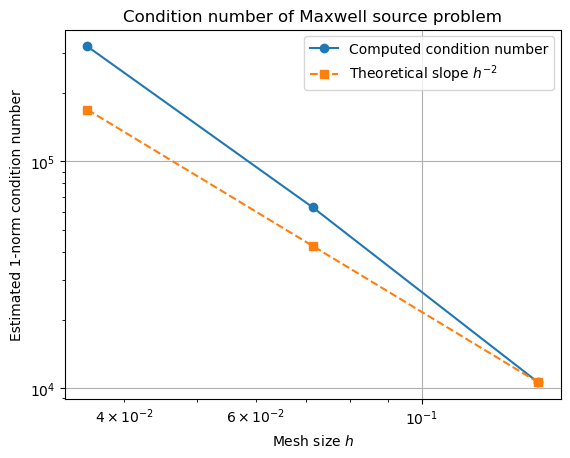

In [16]:
import matplotlib.pyplot as plt

plt.figure()
plt.loglog(hs, conds, "-o", label="Computed condition number")
plt.loglog(hs, conds[0] * (hs / hs[0])**(-2), "--s", label="Theoretical slope $h^{-2}$")
plt.legend()
plt.xlabel("Mesh size $h$")
plt.ylabel("Estimated 1-norm condition number")
plt.title("Condition number of Maxwell source problem")
plt.grid()
plt.show()